In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import Sequential, Model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.layers import Dense, Input, BatchNormalization, Activation
from tensorflow import clip_by_value, reduce_mean
from tensorflow.math import log

### Task 1: Data Loading, Cleaning & Exploratory Data Analysis

In [2]:
# 1.1 Load and inspect the dataset

df = pd.read_csv('Dataset/adult.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nData types: \n{df.dtypes}")


Dataset shape: (48842, 15)

Data types: 
age                int64
workclass            str
fnlwgt             int64
education            str
educational-num    int64
marital-status       str
occupation           str
relationship         str
race                 str
gender               str
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country       str
income               str
dtype: object


In [3]:
display(df.head())

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
for col in df.select_dtypes('str'):
  df[col] = df[col].str.strip()
print('Whitespace removed.')

Whitespace removed.


In [5]:
# 1.2 Handle missing values

df.replace('?', np.nan, inplace = True)
print('Missing values per column: ')
print(df.isnull().sum().sort_values(ascending = False))

rows_before = len(df)
df.dropna(inplace = True)
rows_after = len(df)

print(f"\nTotal rows removed: {rows_before - rows_after}")

Missing values per column: 
occupation         2809
workclass          2799
native-country      857
fnlwgt                0
education             0
educational-num       0
age                   0
marital-status        0
relationship          0
gender                0
race                  0
capital-gain          0
capital-loss          0
hours-per-week        0
income                0
dtype: int64

Total rows removed: 3620


In [6]:
# 1.3 Drop reduntant columns

df.drop(columns = ['fnlwgt', 'education'], inplace = True)
print(f"Dataset shape after dropping columns: {df.shape}")

Dataset shape after dropping columns: (45222, 13)


Value count of 'income': 
income
0    34014
1    11208
Name: count, dtype: int64


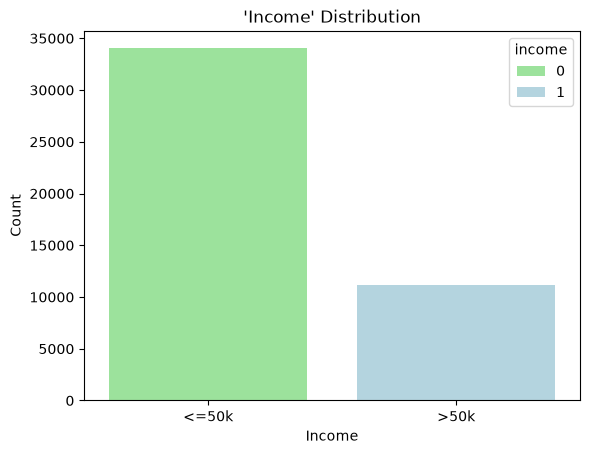

In [7]:
# 1.4 Encode the target

df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})
print(f"Value count of 'income': \n{df['income'].value_counts()}")

sns.countplot(data = df, x = 'income', hue = 'income',palette = ['lightgreen', 'lightblue'])
plt.title("'Income' Distribution")
plt.xlabel('Income')
plt.ylabel('Count')

plt.xticks([0, 1], ['<=50k', '>50k'])
plt.show()

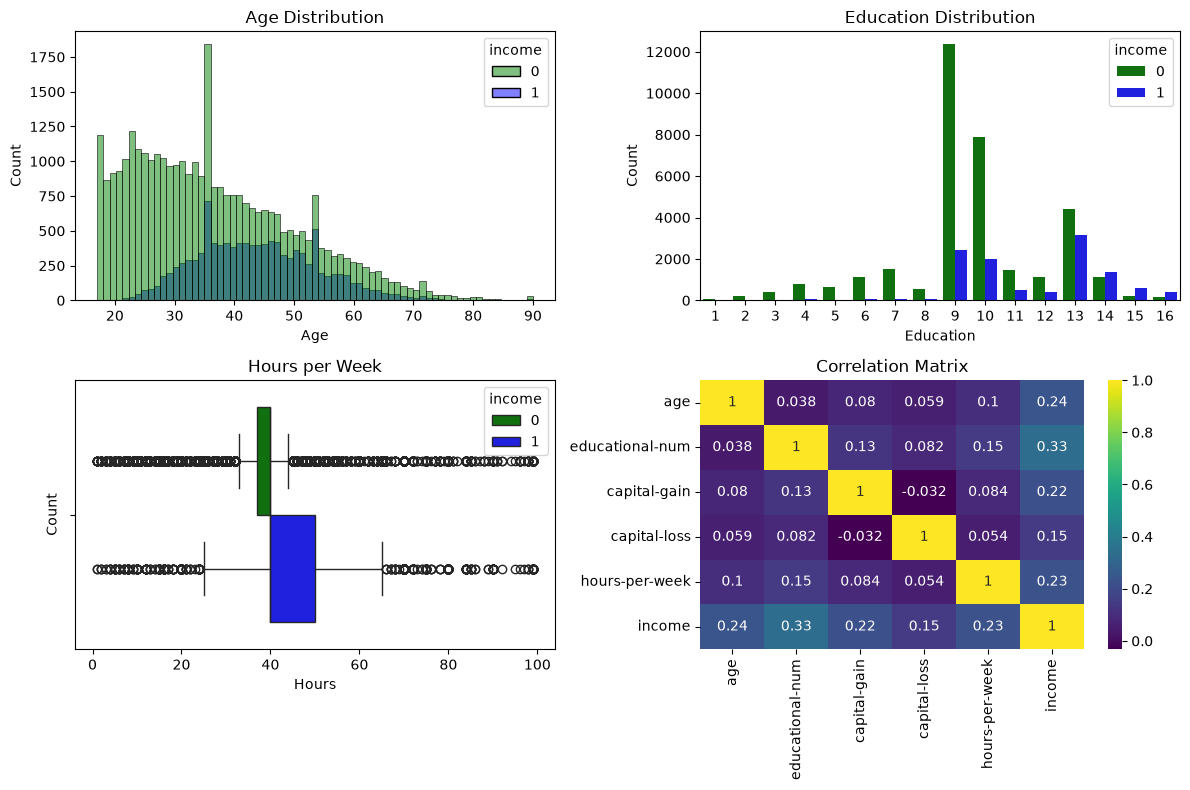

In [8]:
# 1.5 Exploratory visualisations

fig, ax = plt.subplots(2, 2, figsize = (12, 8))

sns.histplot(data = df, x = 'age', hue = 'income', palette = ['green', 'blue'],ax = ax[0,0])
ax[0,0].set_title('Age Distribution')
ax[0,0].set_xlabel('Age')
ax[0,0].set_ylabel('Count')

sns.boxplot(data = df, x = 'hours-per-week' ,hue = 'income', palette = ['green', 'blue'],ax = ax[1,0])
ax[1,0].set_title('Hours per Week')
ax[1,0].set_xlabel('Hours')
ax[1,0].set_ylabel('Count')

sns.countplot(data = df, x = 'educational-num', hue = 'income', palette = ['green', 'blue'],ax = ax[0,1])
ax[0,1].set_title('Education Distribution')
ax[0,1].set_xlabel('Education')
ax[0,1].set_ylabel('Count')

sns.heatmap(df.corr(numeric_only = True), cmap = 'viridis', annot = True ,ax = ax[1,1])
ax[1,1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

In [9]:
# 1.6 Encode categoricals & scale numerics

X = df.drop('income', axis = 1)
y = df['income']

X = pd.get_dummies(X, drop_first=True)
print("Shape after One-Hot Encoding:", X.shape)

numeric_cols = [
    'age',
    'educational-num',
    'hours-per-week',
    'capital-gain',
    'capital-loss',
]

se = StandardScaler()
X[numeric_cols] = se.fit_transform(X[numeric_cols])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 9009, stratify = y)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Shape after One-Hot Encoding: (45222, 80)

X_train shape: (36177, 80)
X_test shape: (9045, 80)
y_train shape: (36177,)
y_test shape: (9045,)


In [10]:
print("\nOriginal class ratio:")
print(y.value_counts(normalize=True).round(2))

print("\nTraining class ratio:")
print(y_train.value_counts(normalize=True).round(2))

print("\nTesting class ratio:")
print(y_test.value_counts(normalize=True).round(2))


Original class ratio:
income
0    0.75
1    0.25
Name: proportion, dtype: float64

Training class ratio:
income
0    0.75
1    0.25
Name: proportion, dtype: float64

Testing class ratio:
income
0    0.75
1    0.25
Name: proportion, dtype: float64


### Task 2: MLP Architecture - Baseline ANN

In [62]:
# 2.1 Define the reusable build_ann() function

def build_ann(input_dim, hidden_units = [128, 64], activation = 'relu', initializer = 'glorot_uniform', use_batch_norm = False, optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy']):

    model = Sequential()
    model.add(Input(shape = (input_dim,)))

    for unit in hidden_units:
        model.add(Dense(unit, kernel_initializer = initializer))
        if use_batch_norm:
            model.add(BatchNormalization())
        model.add(Activation(activation))

    model.add(Dense(1, activation = 'sigmoid'))

    model.compile(optimizer = optimizer, loss = loss, metrics = metrics)

    return model


In [12]:
X_train.shape[1]

80

In [13]:
# 2.2 Baseline ANN architecture

model_base = build_ann(input_dim = X_train.shape[1])

model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,689 (73.00 KB)

 Trainable params: 18,689 (73.00 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# 2.3 Train the baseline

history_base = model_base.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1 ,verbose = 1)

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8387 - loss: 0.3402 - val_accuracy: 0.8458 - val_loss: 0.3259
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8511 - loss: 0.3164 - val_accuracy: 0.8460 - val_loss: 0.3207
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8538 - loss: 0.3132 - val_accuracy: 0.8466 - val_loss: 0.3205
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8553 - loss: 0.3098 - val_accuracy: 0.8469 - val_loss: 0.3223
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8549 - loss: 0.3074 - val_accuracy: 0.8519 - val_loss: 0.3194
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8574 - loss: 0.3048 - val_accuracy: 0.8477 - val_loss: 0.3195
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8587 - loss: 0.3023 - val_accuracy: 0.8472 - val_loss: 0.3244
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8599 - loss: 0.3000 - val_accuracy: 0.

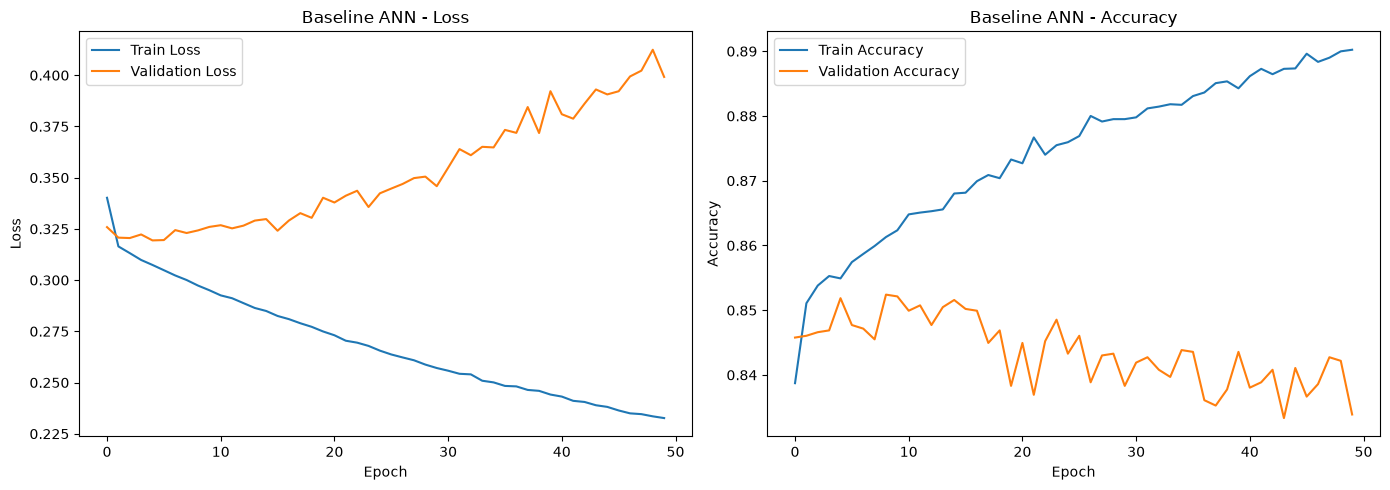

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))


ax[0].plot(history_base.history['loss'], label='Train Loss')
ax[0].plot(history_base.history['val_loss'], label='Validation Loss')
ax[0].set_title('Baseline ANN - Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()


ax[1].plot(history_base.history['accuracy'], label='Train Accuracy')
ax[1].plot(history_base.history['val_accuracy'], label='Validation Accuracy')
ax[1].set_title('Baseline ANN - Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

In [16]:
# 2.4 Evaluate the baseline with full metrics

y_pred_prob = model_base.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred))

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step
              precision    recall  f1-score   support

           0       0.88      0.91      0.90      6803
           1       0.70      0.63      0.67      2242

    accuracy                           0.84      9045
   macro avg       0.79      0.77      0.78      9045
weighted avg       0.84      0.84      0.84      9045



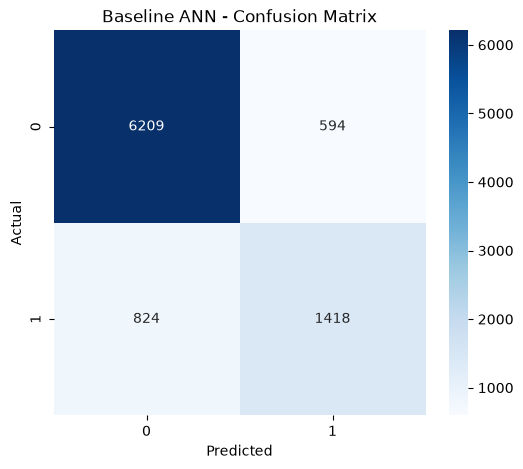

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Baseline ANN - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [18]:
# 2.5

### Task 3: Activation Functions - Comparison Experiment

In [19]:
# 3.1 Train 4 models with different hidden activations

model_relu = build_ann(input_dim = X_train.shape[1], activation = 'relu')
model_tanh = build_ann(input_dim = X_train.shape[1], activation = 'tanh')
model_sigmoid = build_ann(input_dim = X_train.shape[1], activation = 'sigmoid')
model_elu = build_ann(input_dim = X_train.shape[1], activation = 'elu')

history_relu = model_relu.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1 ,verbose = 1)
history_tanh = model_tanh.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1 ,verbose = 1)
history_sigmoid = model_sigmoid.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1 ,verbose = 1)
history_elu = model_elu.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1 ,verbose = 1)



Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8389 - loss: 0.3392 - val_accuracy: 0.8480 - val_loss: 0.3242
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8517 - loss: 0.3164 - val_accuracy: 0.8422 - val_loss: 0.3239
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8536 - loss: 0.3125 - val_accuracy: 0.8494 - val_loss: 0.3187
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8554 - loss: 0.3095 - val_accuracy: 0.8494 - val_loss: 0.3206
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8561 - loss: 0.3072 - val_accuracy: 0.8505 - val_loss: 0.3242
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8582 - loss: 0.3041 - val_accuracy: 0.8480 - val_loss: 0.3216
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8604 - loss: 0.3021 - val_accuracy: 0.8472 - val_loss: 0.3226
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8615 - loss: 0.3002 - val_accuracy: 0.

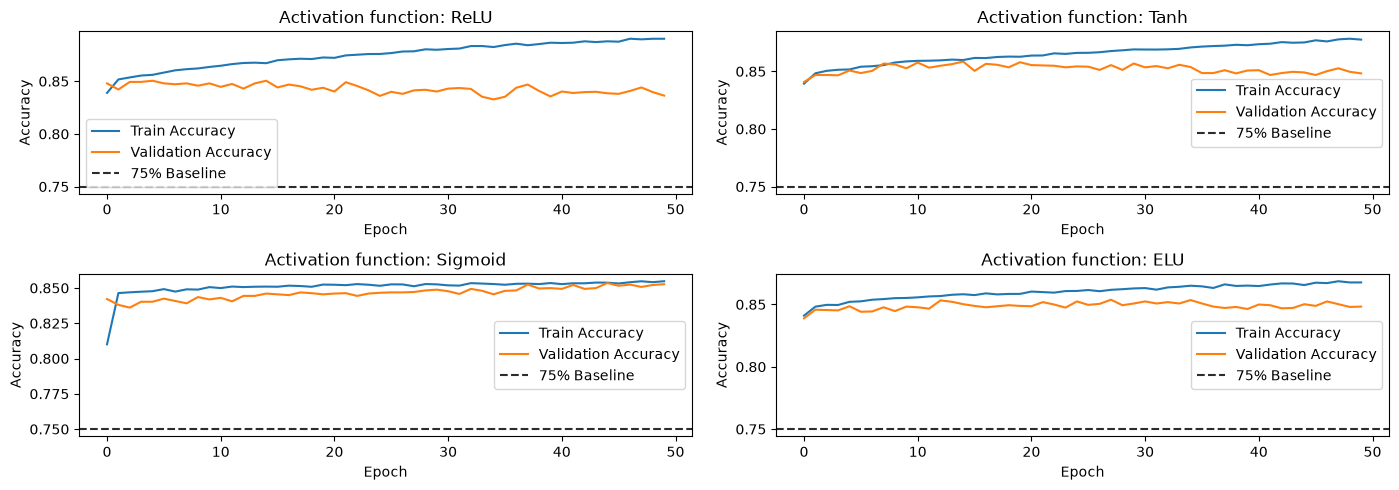

In [20]:
# 3.2 Activation comparison - 4-panel plot

fig, ax = plt.subplots(2,2, figsize = (14,5))

histories = [history_relu, history_tanh, history_sigmoid, history_elu]
activation_names = ['ReLU', 'Tanh', 'Sigmoid', 'ELU']

for i, history in enumerate(histories):
    row = i // 2
    col = i % 2

    ax[row,col].plot(history.history['accuracy'], label='Train Accuracy')
    ax[row,col].plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax[row,col].set_title(f"Activation function: {activation_names[i]}")
    ax[row, col].axhline(
        y=0.75,
        linestyle='--',
        color='#2C2C2C',
        label='75% Baseline'
    )
    ax[row,col].set_xlabel('Epoch')
    ax[row,col].set_ylabel('Accuracy')
    ax[row,col].legend()

plt.tight_layout()
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Fraction of dead activations (ReLU, first hidden layer): 0.6173


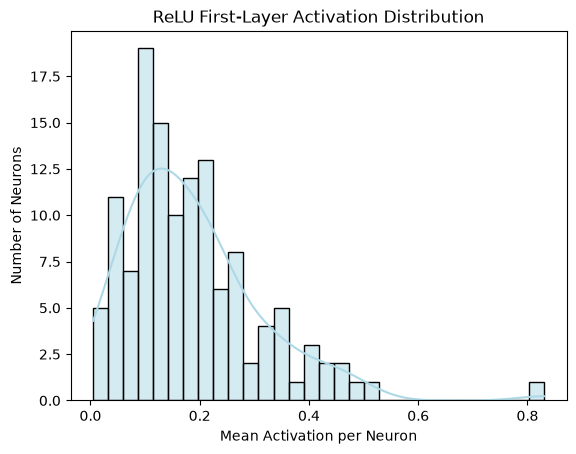

In [21]:
# 3.3 Dead neuron check - ReLU

inp = Input(shape = (X_train.shape[1],))
out = model_relu.layers[0](inp)

intermediate = Model(inputs = inp, outputs = out)
activations = intermediate.predict(X_test[:500])
dead_fraction = np.mean(activations == 0)
print(f"Fraction of dead activations (ReLU, first hidden layer): {dead_fraction:.4f}")


mean_activation_per_neuron = activations.mean(axis = 0)
sns.histplot(x = mean_activation_per_neuron, bins = 30, kde = True, color = 'lightblue')
plt.title('ReLU First-Layer Activation Distribution')
plt.xlabel('Mean Activation per Neuron')
plt.ylabel('Number of Neurons')
plt.show()

In [22]:
# 3.4 Gradient flow check - Sigmoid hidden layers


In [23]:
# 3.5 Activation summary Markdown table

### Task 4: Weight Initialization Techniques

In [24]:
# 4.1 Train 5 models with different initialisers

model_glorot_uniform = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'glorot_uniform')
model_glorot_normal  = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'glorot_normal')
model_he_uniform     = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'he_uniform')
model_he_normal      = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'he_normal')
model_zeros          = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'zeros')

history_glorot_uniform = model_glorot_uniform.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1, verbose = 1)
history_glorot_normal  = model_glorot_normal.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1, verbose = 1)
history_he_uniform     = model_he_uniform.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1, verbose = 1)
history_he_normal      = model_he_normal.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1, verbose = 1)
history_zeros          = model_zeros.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1, verbose = 1)


Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8421 - loss: 0.3386 - val_accuracy: 0.8347 - val_loss: 0.3308
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8515 - loss: 0.3162 - val_accuracy: 0.8477 - val_loss: 0.3250
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8554 - loss: 0.3123 - val_accuracy: 0.8505 - val_loss: 0.3231
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8575 - loss: 0.3092 - val_accuracy: 0.8466 - val_loss: 0.3211
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8580 - loss: 0.3064 - val_accuracy: 0.8513 - val_loss: 0.3214
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8599 - loss: 0.3042 - val_accuracy: 0.8516 - val_loss: 0.3195
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8603 - loss: 0.3016 - val_accuracy: 0.8502 - val_loss: 0.3215
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8616 - loss: 0.3004 - val_accuracy: 0.

In [25]:
# 4.2 Why initialisation matters - Markdown

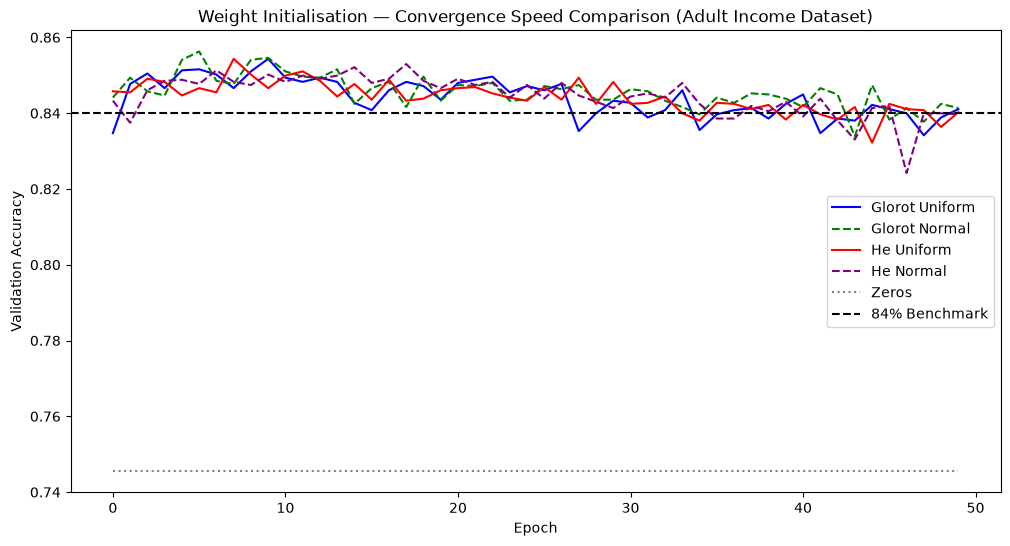

In [26]:
# 4.3 Convergence speed comparison plot

plt.figure(figsize=(12, 6))

plt.plot(history_glorot_uniform.history['val_accuracy'], label='Glorot Uniform', color='blue', linestyle='-')
plt.plot(history_glorot_normal.history['val_accuracy'], label='Glorot Normal', color='green', linestyle='--')
plt.plot(history_he_uniform.history['val_accuracy'], label='He Uniform', color='red', linestyle='-')
plt.plot(history_he_normal.history['val_accuracy'], label='He Normal', color='purple', linestyle='--')
plt.plot(history_zeros.history['val_accuracy'], label='Zeros', color='gray', linestyle=':')

plt.axhline(y=0.84, color='black', linestyle='--', label='84% Benchmark')

plt.title('Weight Initialisation — Convergence Speed Comparison (Adult Income Dataset)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

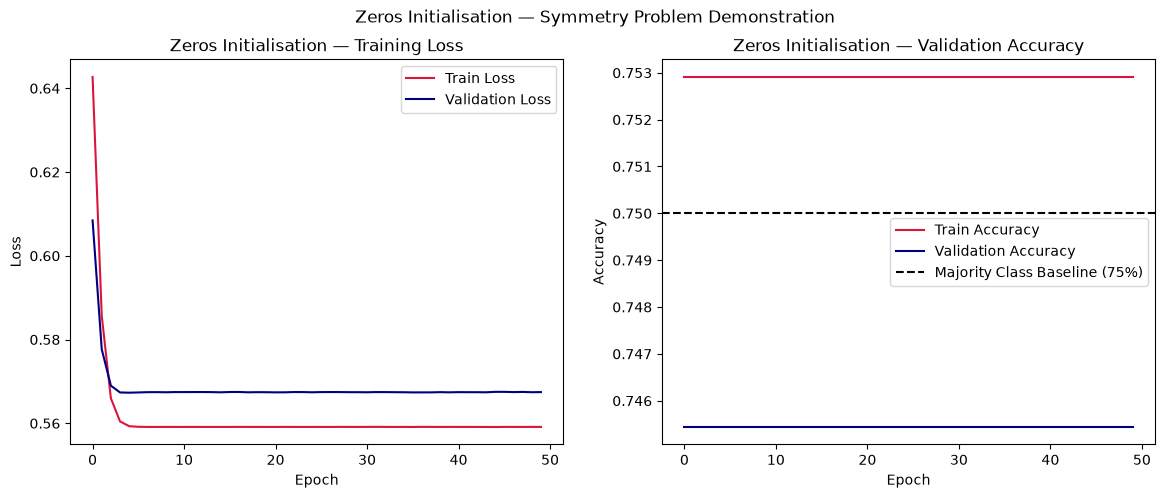

In [27]:
# 4.4 Zeros failure demonstration

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(history_zeros.history['loss'], label='Train Loss', color='crimson')
ax[0].plot(history_zeros.history['val_loss'], label='Validation Loss', color='navy')
ax[0].set_title('Zeros Initialisation — Training Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].plot(history_zeros.history['accuracy'], label='Train Accuracy', color='crimson')
ax[1].plot(history_zeros.history['val_accuracy'], label='Validation Accuracy', color='navy')
ax[1].axhline(y=0.75, color='black', linestyle='--', label='Majority Class Baseline (75%)')
ax[1].set_title('Zeros Initialisation — Validation Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.suptitle('Zeros Initialisation — Symmetry Problem Demonstration')
plt.show()

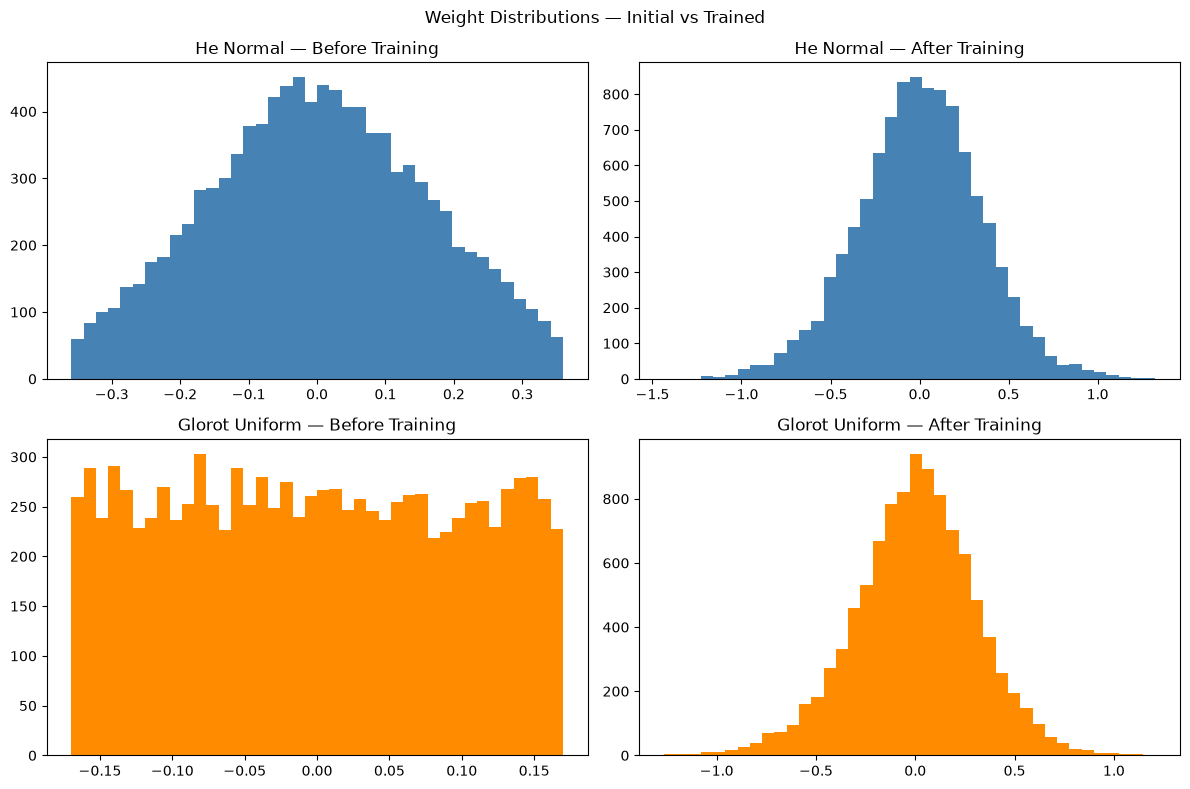

In [28]:
# 4.5 Weight distribution visualisation

model_he_normal_init = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'he_normal')
model_glorot_uniform_init = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'glorot_uniform')

he_weights_before = model_he_normal_init.layers[0].get_weights()[0].flatten()
glorot_weights_before = model_glorot_uniform_init.layers[0].get_weights()[0].flatten()


he_weights_after = model_he_normal.layers[0].get_weights()[0].flatten()
glorot_weights_after = model_glorot_uniform.layers[0].get_weights()[0].flatten()

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0,0].hist(he_weights_before, bins=40, color='steelblue')
ax[0,0].set_title('He Normal — Before Training')

ax[0,1].hist(he_weights_after, bins=40, color='steelblue')
ax[0,1].set_title('He Normal — After Training')

ax[1,0].hist(glorot_weights_before, bins=40, color='darkorange')
ax[1,0].set_title('Glorot Uniform — Before Training')

ax[1,1].hist(glorot_weights_after, bins=40, color='darkorange')
ax[1,1].set_title('Glorot Uniform — After Training')

plt.suptitle('Weight Distributions — Initial vs Trained')
plt.tight_layout()
plt.show()

### Task 5: Loss Funtions

In [29]:
# 5.1 Binary Cross-Entropy - the correct loss

print(f"Baseline model loss function: {model_base.loss}")

Baseline model loss function: binary_crossentropy


In [33]:
# 5.2 MSE as classification loss - wrong tool experiment

model_mse = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'he_normal', loss = 'mean_squared_error')

history_mse = model_mse.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1, verbose = 1)

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8443 - loss: 0.1080 - val_accuracy: 0.8452 - val_loss: 0.1064
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8513 - loss: 0.1013 - val_accuracy: 0.8447 - val_loss: 0.1038
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8548 - loss: 0.1000 - val_accuracy: 0.8494 - val_loss: 0.1056
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8577 - loss: 0.0982 - val_accuracy: 0.8510 - val_loss: 0.1034
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8602 - loss: 0.0972 - val_accuracy: 0.8532 - val_loss: 0.1036
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8607 - loss: 0.0962 - val_accuracy: 0.8505 - val_loss: 0.1045
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8630 - loss: 0.0952 - val_accuracy: 0.8527 - val_loss: 0.1044
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8649 - loss: 0.0942 - val_accuracy: 0.

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 662us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 690us/step


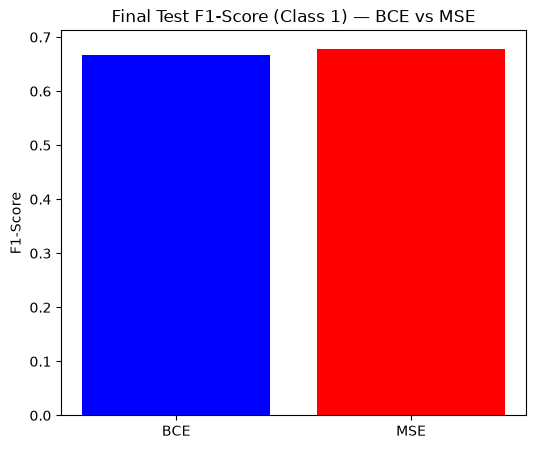

In [34]:
y_pred_base = (model_base.predict(X_test) >= 0.50).astype(int)
y_pred_mse = (model_mse.predict(X_test) >= 0.50).astype(int)

f1_base = f1_score(y_test, y_pred_base)
f1_mse = f1_score(y_test, y_pred_mse)

plt.figure(figsize = (6, 5))
plt.bar(['BCE', 'MSE'], [f1_base, f1_mse], color = ['blue', 'red'])
plt.title('Final Test F1-Score (Class 1) — BCE vs MSE')
plt.ylabel('F1-Score')
plt.show()

In [40]:
# 5.3 Weighted Binary Cross-Entropy - handling class imbalance

weights = compute_class_weight('balanced', classes = np.array([0, 1]), y = y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}

model_wbce = build_ann(input_dim = X_train.shape[1], loss = 'binary_crossentropy', activation = 'relu', initializer = 'he_normal')

history_wbce = model_wbce.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1, verbose = 1, class_weight = class_weight_dict)

y_pred_wbce = (model_wbce.predict(X_test) >= 0.50).astype(int)

precision_base = precision_score(y_test, y_pred_base)
recall_base = recall_score(y_test, y_pred_base)

precision_wbce = precision_score(y_test, y_pred_wbce)
recall_wbce = recall_score(y_test, y_pred_wbce)
f1_wbce = f1_score(y_test, y_pred_wbce)

metrics_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1'],
    'model_base': [precision_base, recall_base, f1_base],
    'model_wbce': [precision_wbce, recall_wbce, f1_wbce]
})
print(metrics_df)


Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7961 - loss: 0.3998 - val_accuracy: 0.7897 - val_loss: 0.4171
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8106 - loss: 0.3752 - val_accuracy: 0.7996 - val_loss: 0.3919
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8114 - loss: 0.3694 - val_accuracy: 0.7971 - val_loss: 0.3927
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8138 - loss: 0.3659 - val_accuracy: 0.7980 - val_loss: 0.3918
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8146 - loss: 0.3620 - val_accuracy: 0.7894 - val_loss: 0.4195
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8177 - loss: 0.3585 - val_accuracy: 0.8054 - val_loss: 0.3715
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8181 - loss: 0.3554 - val_accuracy: 0.8154 - val_loss: 0.3620
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8202 - loss: 0.3514 - val_accuracy: 0.

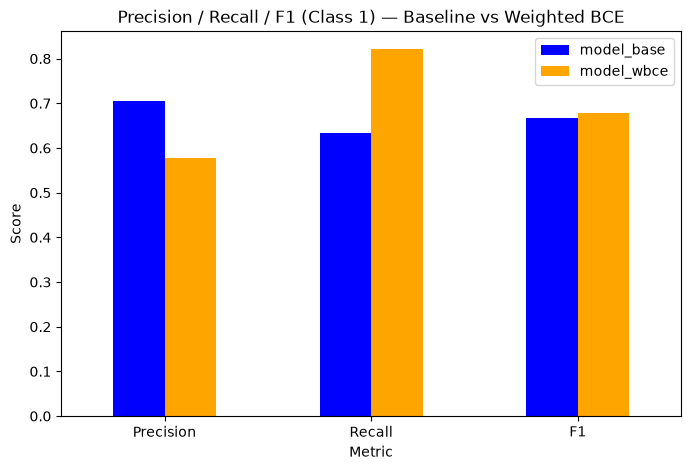

In [41]:
metrics_df.plot(x='Metric', kind='bar', figsize=(8, 5), color=['blue', 'orange'])
plt.title('Precision / Recall / F1 (Class 1) — Baseline vs Weighted BCE')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

In [46]:
# 5.4 Focal Loss - advanced imbalance handling

def focal_loss(gamma = 2.0, alpha = 0.25):
    def loss(y_true, y_pred):
        y_pred = clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * log(y_pred) - (1 - y_true) * log(1 - y_pred)
        weight = alpha * y_true * (1 - y_pred) ** gamma + (1 - alpha) * (1 - y_true) * y_pred ** gamma

        return reduce_mean(weight * bce)
    return loss

model_focal = build_ann(input_dim = X_train.shape[1], loss = focal_loss(gamma = 2.0, alpha = 0.25), activation = 'relu', initializer = 'he_normal')

history_focal = model_focal.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1, verbose = 1)


y_pred_focal = (model_focal.predict(X_test) >= 0.5).astype(int)
recall_focal = recall_score(y_test, y_pred_focal)
f1_focal = f1_score(y_test, y_pred_focal)

print(f"model_base  - Recall: {recall_base:.4f}, F1: {f1_base:.4f}")
print(f"model_wbce  - Recall: {recall_wbce:.4f}, F1: {f1_wbce:.4f}")
print(f"model_focal - Recall: {recall_focal:.4f}, F1: {f1_focal:.4f}")

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8124 - loss: 0.0371 - val_accuracy: 0.8289 - val_loss: 0.0332
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8271 - loss: 0.0327 - val_accuracy: 0.8311 - val_loss: 0.0331
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8288 - loss: 0.0323 - val_accuracy: 0.7971 - val_loss: 0.0348
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8301 - loss: 0.0320 - val_accuracy: 0.8214 - val_loss: 0.0330
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8324 - loss: 0.0315 - val_accuracy: 0.8295 - val_loss: 0.0331
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8331 - loss: 0.0313 - val_accuracy: 0.8242 - val_loss: 0.0330
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8338 - loss: 0.0310 - val_accuracy: 0.8264 - val_loss: 0.0331
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8351 - loss: 0.0307 - val_accuracy: 0.

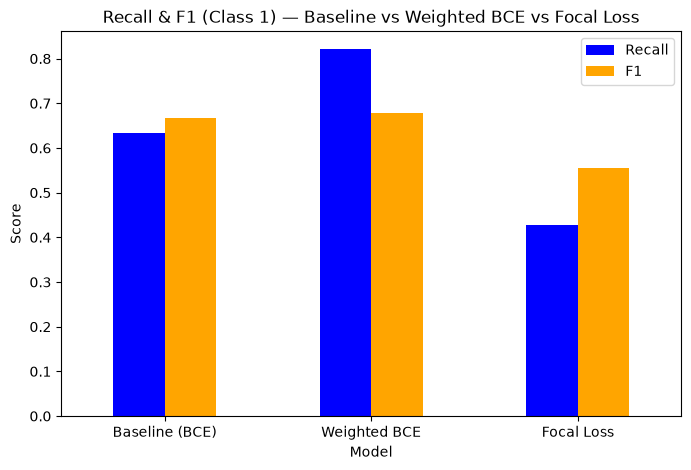

In [47]:
compare_df = pd.DataFrame({
    'Model': ['Baseline (BCE)', 'Weighted BCE', 'Focal Loss'],
    'Recall': [recall_base, recall_wbce, recall_focal],
    'F1': [f1_base, f1_wbce, f1_focal]
})

compare_df.plot(x='Model', kind='bar', figsize=(8, 5), color=['blue', 'orange', 'green'])
plt.title('Recall & F1 (Class 1) — Baseline vs Weighted BCE vs Focal Loss')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()


In [ ]:
# 5.5 Loss function summary Markdown table

### Task 6: Batch Normalization

In [49]:
# 6.1 Build ANN with Batch Normalization

model_bn = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, kernel_initializer='he_normal', activation = 'relu'),
    BatchNormalization(),
    Dense(64, kernel_initializer='he_normal', activation = 'relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

model_bn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_bn.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_51 (Dense)                │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,457 (76.00 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# 6.2 Why Batch Normalization - Markdown

In [52]:
# 6.3 Train and compare: with vs without BatchNorm

history_bn = model_bn.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1, verbose = 1)

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8319 - loss: 0.3708 - val_accuracy: 0.8472 - val_loss: 0.3289
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8482 - loss: 0.3228 - val_accuracy: 0.8494 - val_loss: 0.3242
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8500 - loss: 0.3195 - val_accuracy: 0.8510 - val_loss: 0.3229
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8515 - loss: 0.3142 - val_accuracy: 0.8510 - val_loss: 0.3192
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8554 - loss: 0.3102 - val_accuracy: 0.8447 - val_loss: 0.3192
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8548 - loss: 0.3073 - val_accuracy: 0.8502 - val_loss: 0.3227
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8591 - loss: 0.3036 - val_accuracy: 0.8485 - val_loss: 0.3207
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8575 - loss: 0.3024 - val_accuracy: 0.

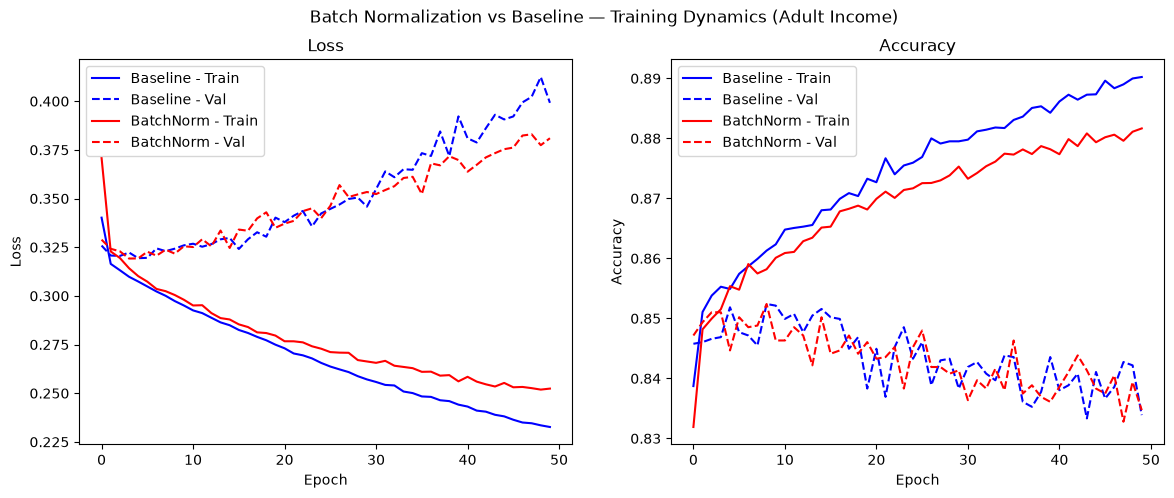

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(history_base.history['loss'], label='Baseline - Train', color='blue')
ax[0].plot(history_base.history['val_loss'], label='Baseline - Val', color='blue', linestyle='--')
ax[0].plot(history_bn.history['loss'], label='BatchNorm - Train', color='red')
ax[0].plot(history_bn.history['val_loss'], label='BatchNorm - Val', color='red', linestyle='--')
ax[0].set_title('Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].plot(history_base.history['accuracy'], label='Baseline - Train', color='blue')
ax[1].plot(history_base.history['val_accuracy'], label='Baseline - Val', color='blue', linestyle='--')
ax[1].plot(history_bn.history['accuracy'], label='BatchNorm - Train', color='red')
ax[1].plot(history_bn.history['val_accuracy'], label='BatchNorm - Val', color='red', linestyle='--')
ax[1].set_title('Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.suptitle('Batch Normalization vs Baseline — Training Dynamics (Adult Income)')
plt.show()

In [54]:
y_pred_bn = (model_bn.predict(X_test) >= 0.5).astype(int)

acc_base = accuracy_score(y_test, y_pred_base)
acc_bn = accuracy_score(y_test, y_pred_bn)
f1_bn = f1_score(y_test, y_pred_bn)

print(f"Baseline  - Accuracy: {acc_base:.4f}, F1 (class 1): {f1_base:.4f}")
print(f"BatchNorm - Accuracy: {acc_bn:.4f}, F1 (class 1): {f1_bn:.4f}")

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step
Baseline  - Accuracy: 0.8432, F1 (class 1): 0.6667
BatchNorm - Accuracy: 0.8447, F1 (class 1): 0.6569


In [57]:
# 6.4 BatchNorm position experiment

model_bn_after = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, kernel_initializer='he_normal'),
    Activation('relu'),
    BatchNormalization(),
    Dense(64, kernel_initializer='he_normal'),
    Activation('relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])
model_bn_after.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


model_bn_before = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, kernel_initializer='he_normal'),
    BatchNormalization(),
    Activation('relu'),
    Dense(64, kernel_initializer='he_normal'),
    BatchNormalization(),
    Activation('relu'),
    Dense(1, activation='sigmoid')
])
model_bn_before.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_bn_after = model_bn_after.fit(X_train, y_train, epochs=30, batch_size=64, validation_split=0.1, verbose=1)
history_bn_before = model_bn_before.fit(X_train, y_train, epochs=30, batch_size=64, validation_split=0.1, verbose=1)

Epoch 1/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8320 - loss: 0.3699 - val_accuracy: 0.8411 - val_loss: 0.3349
Epoch 2/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8490 - loss: 0.3224 - val_accuracy: 0.8472 - val_loss: 0.3233
Epoch 3/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8537 - loss: 0.3152 - val_accuracy: 0.8441 - val_loss: 0.3262
Epoch 4/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8533 - loss: 0.3134 - val_accuracy: 0.8436 - val_loss: 0.3226
Epoch 5/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8568 - loss: 0.3077 - val_accuracy: 0.8496 - val_loss: 0.3218
Epoch 6/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8589 - loss: 0.3053 - val_accuracy: 0.8419 - val_loss: 0.3252
Epoch 7/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8576 - loss: 0.3018 - val_accuracy: 0.8488 - val_loss: 0.3247
Epoch 8/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8583 - loss: 0.3004 - val_accuracy: 0.

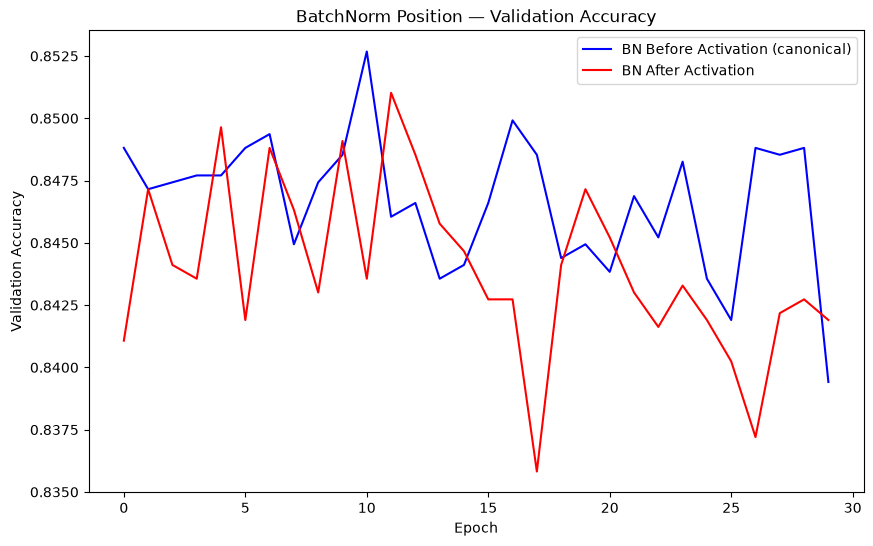

In [58]:
plt.figure(figsize=(10, 6))
plt.plot(history_bn_before.history['val_accuracy'], label='BN Before Activation (canonical)', color='blue')
plt.plot(history_bn_after.history['val_accuracy'], label='BN After Activation', color='red')
plt.title('BatchNorm Position — Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

In [59]:
final_acc_before = history_bn_before.history['val_accuracy'][-1]
final_acc_after = history_bn_after.history['val_accuracy'][-1]
print(f"Final val accuracy - BN Before Activation: {final_acc_before:.4f}")
print(f"Final val accuracy - BN After Activation: {final_acc_after:.4f}")

Final val accuracy - BN Before Activation: 0.8394
Final val accuracy - BN After Activation: 0.8419


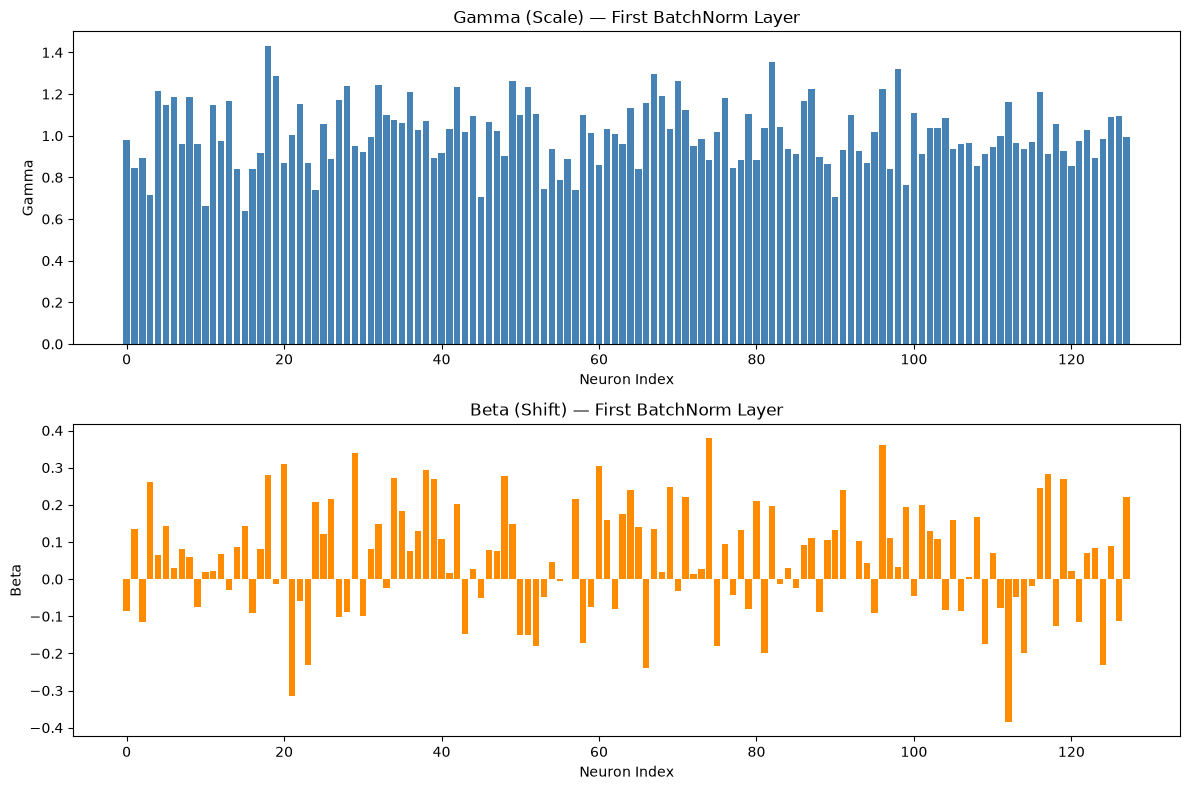

In [61]:
# 6.5 Inspect learned gamma and beta

bn_layer = model_bn.layers[1]
gamma, beta, running_mean, running_var = bn_layer.get_weights()

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

ax[0].bar(range(len(gamma)), gamma, color='steelblue')
ax[0].set_title('Gamma (Scale) — First BatchNorm Layer')
ax[0].set_xlabel('Neuron Index')
ax[0].set_ylabel('Gamma')

ax[1].bar(range(len(beta)), beta, color='darkorange')
ax[1].set_title('Beta (Shift) — First BatchNorm Layer')
ax[1].set_xlabel('Neuron Index')
ax[1].set_ylabel('Beta')

plt.tight_layout()
plt.show()

### Task 7: Optimizers - Covergence & Final Comaparison

In [64]:
# 7.1 Build 5 models with different optimisers

model_sgd = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'he_normal', use_batch_norm = True, optimizer = 'sgd', loss = 'binary_crossentropy')

model_sgd_momentum = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'he_normal', use_batch_norm = True, optimizer = SGD(learning_rate=0.01, momentum=0.9), loss = 'binary_crossentropy')

model_rmsprop = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'he_normal', use_batch_norm = True, optimizer = 'rmsprop', loss = 'binary_crossentropy')

model_adam = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'he_normal', use_batch_norm = True, optimizer = 'adam', loss = 'binary_crossentropy')

model_adam_explicit = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'he_normal', use_batch_norm = True, optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999), loss = 'binary_crossentropy')

history_sgd = model_sgd.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1, verbose = 1)
history_sgd_momentum = model_sgd_momentum.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1, verbose = 1)
history_rmsprop = model_rmsprop.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1, verbose = 1)
history_adam = model_adam.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1, verbose = 1)
history_adam_explicit = model_adam_explicit.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1, verbose = 1)

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8151 - loss: 0.4011 - val_accuracy: 0.8344 - val_loss: 0.3546
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8369 - loss: 0.3483 - val_accuracy: 0.8389 - val_loss: 0.3416
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8434 - loss: 0.3382 - val_accuracy: 0.8422 - val_loss: 0.3360
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8439 - loss: 0.3341 - val_accuracy: 0.8427 - val_loss: 0.3334
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8437 - loss: 0.3309 - val_accuracy: 0.8438 - val_loss: 0.3298
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8448 - loss: 0.3299 - val_accuracy: 0.8438 - val_loss: 0.3291
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8477 - loss: 0.3262 - val_accuracy: 0.8469 - val_loss: 0.3267
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8482 - loss: 0.3249 - val_accuracy: 0.

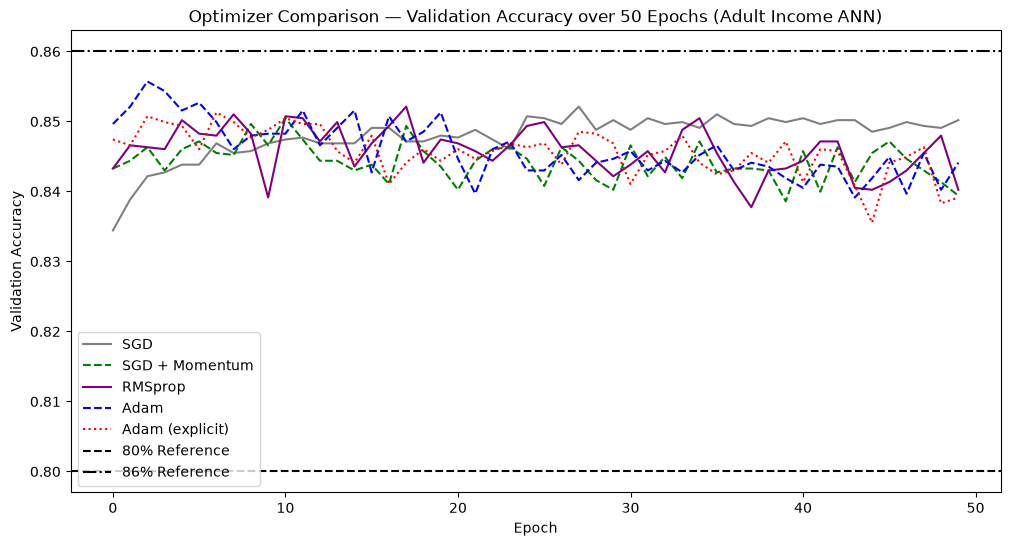

In [65]:
# 7.2 Optimiser convergence plot

plt.figure(figsize=(12, 6))

plt.plot(history_sgd.history['val_accuracy'], label='SGD', color='gray', linestyle='-')
plt.plot(history_sgd_momentum.history['val_accuracy'], label='SGD + Momentum', color='green', linestyle='--')
plt.plot(history_rmsprop.history['val_accuracy'], label='RMSprop', color='purple', linestyle='-')
plt.plot(history_adam.history['val_accuracy'], label='Adam', color='blue', linestyle='--')
plt.plot(history_adam_explicit.history['val_accuracy'], label='Adam (explicit)', color='red', linestyle=':')

plt.axhline(y=0.80, color='black', linestyle='--', label='80% Reference')
plt.axhline(y=0.86, color='black', linestyle='-.', label='86% Reference')

plt.title('Optimizer Comparison — Validation Accuracy over 50 Epochs (Adult Income ANN)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

In [ ]:
# 7.3 Why Adam dominates - Markdown

In [68]:
# 7.4 Learning rate sensitivity - SGD vs Adam

sgd_lrs = [0.0001, 0.001, 0.01, 0.1]
adam_lrs = [0.0001, 0.001, 0.01]

sgd_histories = []
for lr in sgd_lrs:
    model = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'he_normal', use_batch_norm = True, optimizer = SGD(learning_rate = lr), loss = 'binary_crossentropy')
    hist = model.fit(X_train, y_train, epochs = 30, batch_size = 64, validation_split = 0.1, verbose = 0)
    sgd_histories.append(hist)
    print(f"SGD lr = {lr} done")

adam_histories = []
for lr in adam_lrs:
    model = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'he_normal', use_batch_norm = True, optimizer = Adam(learning_rate = lr), loss = 'binary_crossentropy')
    hist = model.fit(X_train, y_train, epochs = 30, batch_size = 64, validation_split = 0.1, verbose = 0)
    adam_histories.append(hist)
    print(f"Adam lr = {lr} done")


SGD lr = 0.0001 done
SGD lr = 0.001 done
SGD lr = 0.01 done
SGD lr = 0.1 done
Adam lr = 0.0001 done
Adam lr = 0.001 done
Adam lr = 0.01 done


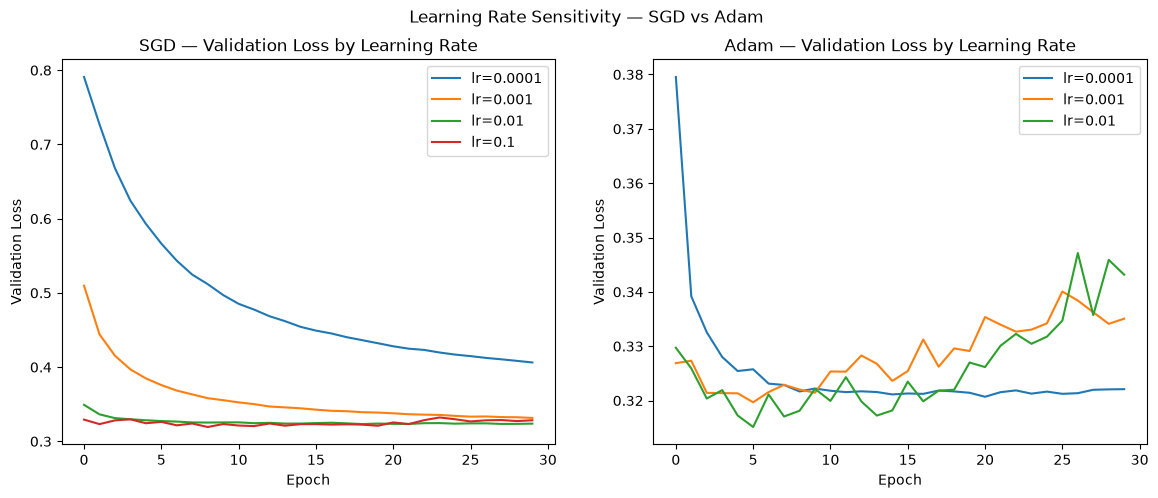

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for lr, hist in zip(sgd_lrs, sgd_histories):
    ax[0].plot(hist.history['val_loss'], label=f'lr={lr}')
ax[0].set_title('SGD — Validation Loss by Learning Rate')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Validation Loss')
ax[0].legend()

for lr, hist in zip(adam_lrs, adam_histories):
    ax[1].plot(hist.history['val_loss'], label=f'lr={lr}')
ax[1].set_title('Adam — Validation Loss by Learning Rate')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Validation Loss')
ax[1].legend()

plt.suptitle('Learning Rate Sensitivity — SGD vs Adam')
plt.show()

In [71]:
# 7.5 Final Combined ANN - best configuration

model_final = build_ann(input_dim = X_train.shape[1], hidden_units = [128, 64], activation = 'relu', initializer = 'he_normal', use_batch_norm = True, optimizer = 'adam', loss = 'binary_crossentropy')

history_final = model_final.fit(X_train, y_train, epochs = 80, batch_size = 64, validation_split = 0.1, class_weight = class_weight_dict, verbose = 1)

y_pred_prob_final = model_final.predict(X_test).flatten()
y_pred_final = (y_pred_prob_final >= 0.5).astype(int)

acc_final = accuracy_score(y_test, y_pred_final)
prec_final = precision_score(y_test, y_pred_final)
rec_final = recall_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)
auc_final = roc_auc_score(y_test, y_pred_prob_final)

print(f"Final Combined Model — Test Set Metrics")
print(f"Accuracy:  {acc_final:.4f}")
print(f"Precision (class 1): {prec_final:.4f}")
print(f"Recall (class 1):    {rec_final:.4f}")
print(f"F1 (class 1):        {f1_final:.4f}")
print(f"ROC-AUC:   {auc_final:.4f}")

Epoch 1/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7910 - loss: 0.4043 - val_accuracy: 0.8010 - val_loss: 0.3826
Epoch 2/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8080 - loss: 0.3804 - val_accuracy: 0.8029 - val_loss: 0.3801
Epoch 3/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8101 - loss: 0.3741 - val_accuracy: 0.8007 - val_loss: 0.3821
Epoch 4/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8094 - loss: 0.3701 - val_accuracy: 0.8126 - val_loss: 0.3653
Epoch 5/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8122 - loss: 0.3674 - val_accuracy: 0.8074 - val_loss: 0.3728
Epoch 6/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8150 - loss: 0.3625 - val_accuracy: 0.7982 - val_loss: 0.3887
Epoch 7/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8177 - loss: 0.3602 - val_accuracy: 0.8098 - val_loss: 0.3702
Epoch 8/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8168 - loss: 0.3577 - val_accuracy: 0.

In [74]:
# 7.6 Full results comparison table

def get_metrics(model, name, activation, initializer, loss_name, batchnorm, optimizer_name):
    y_prob = model.predict(X_test).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        'Model': name,
        'Activation': activation,
        'Init': initializer,
        'Loss': loss_name,
        'BatchNorm': batchnorm,
        'Optimizer': optimizer_name,
        'Test Acc': accuracy_score(y_test, y_pred),
        'Prec(1)': precision_score(y_test, y_pred),
        'Recall(1)': recall_score(y_test, y_pred),
        'F1(1)': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

results = [
    get_metrics(model_base, 'Baseline', 'relu', 'glorot_uniform', 'BCE', False, 'adam'),
    get_metrics(model_relu, 'Best Activation (ReLU)', 'relu', 'glorot_uniform', 'BCE', False, 'adam'),
    get_metrics(model_he_normal, 'Best Initialiser (He Normal)', 'relu', 'he_normal', 'BCE', False, 'adam'),
    get_metrics(model_wbce, 'Weighted BCE', 'relu', 'he_normal', 'Weighted BCE', False, 'adam'),
    get_metrics(model_focal, 'Focal Loss', 'relu', 'he_normal', 'Focal Loss', False, 'adam'),
    get_metrics(model_bn, 'BatchNorm', 'relu', 'he_normal', 'BCE', True, 'adam'),
    get_metrics(model_final, 'Final Combined', 'relu', 'he_normal', 'BCE (weighted)', True, 'adam'),
]

results_df = pd.DataFrame(results)
display(results_df.style.highlight_max(subset=['F1(1)', 'ROC-AUC'], color='#ffcccc'))


283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Model,Activation,Init,Loss,BatchNorm,Optimizer,Test Acc,Prec(1),Recall(1),F1(1),ROC-AUC
0,Baseline,relu,glorot_uniform,BCE,False,adam,0.843228,0.704771,0.632471,0.666667,0.890080
1,Best Activation (ReLU),relu,glorot_uniform,BCE,False,adam,0.843449,0.724946,0.593666,0.652771,0.889485
2,Best Initialiser (He Normal),relu,he_normal,BCE,False,adam,0.844334,0.698571,0.654326,0.675725,0.894439
3,Weighted BCE,relu,he_normal,Weighted BCE,False,adam,0.806744,0.577527,0.820696,0.677966,0.894172
4,Focal Loss,relu,he_normal,Focal Loss,False,adam,0.829961,0.790429,0.427297,0.554719,0.888368
5,BatchNorm,relu,he_normal,BCE,True,adam,0.844666,0.725850,0.599911,0.656899,0.895076
6,Final Combined,relu,he_normal,BCE (weighted),True,adam,0.806633,0.577345,0.820696,0.677841,0.896948
